<a href="https://colab.research.google.com/github/jiminmini/mini/blob/ESAA_OB_%EC%84%B8%EC%85%98(%EA%B8%88)/11_14_%EC%84%B8%EC%85%98_%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%98_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. PyTorch Workflow Exercise Template

The following is a template for the PyTorch workflow exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
# Setup device-agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

## 1. Create a straight line dataset using the linear regression formula (`weight * X + bias`).
  * Set `weight=0.3` and `bias=0.9` there should be at least 100 datapoints total.
  * Split the data into 80% training, 20% testing.
  * Plot the training and testing data so it becomes visual.

Your output of the below cell should look something like:
```
Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900])
y: tensor([0.9000, 0.9030, 0.9060, 0.9090, 0.9120, 0.9150, 0.9180, 0.9210, 0.9240,
        0.9270])
```

Of course the numbers in `X` and `y` may be different but ideally they're created using the linear regression formula.

In [2]:
import torch
import matplotlib.pyplot as plt

# Create the data parameters
weight = 0.3
bias = 0.9
num_samples = 100

# Make X and y using linear regression formula
X = torch.linspace(0, 1, num_samples)  # 0~1 사이 num_samples 점
y = weight * X + bias

print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\ny: {y[:10]}")

Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0101, 0.0202, 0.0303, 0.0404, 0.0505, 0.0606, 0.0707, 0.0808,
        0.0909])
y: tensor([0.9000, 0.9030, 0.9061, 0.9091, 0.9121, 0.9152, 0.9182, 0.9212, 0.9242,
        0.9273])


In [3]:
# Split the data into training and testing
split_idx = int(0.8 * num_samples)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

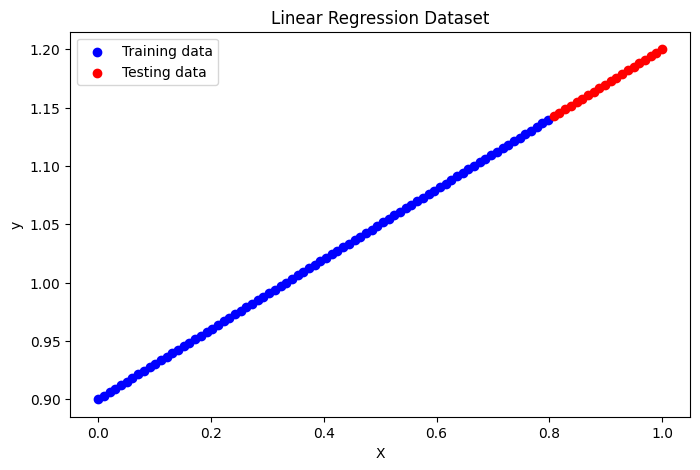

In [4]:
# Plot the training and testing data
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Testing data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Dataset')
plt.legend()
plt.show()

## 2. Build a PyTorch model by subclassing `nn.Module`.
  * Inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`.
  * Implement the `forward()` method to compute the linear regression function you used to create the dataset in 1.
  * Once you've constructed the model, make an instance of it and check its `state_dict()`.
  * **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter()` you can.

In [5]:
# Create PyTorch linear regression model by subclassing nn.Module
import torch
import torch.nn as nn

# Create PyTorch linear regression model by subclassing nn.Module
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Randomly initialized weight and bias with requires_grad=True
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True))

    def forward(self, x):
        # Linear regression function: y = weight * x + bias
        return self.weight * x + self.bias

In [6]:
# Instantiate the model and put it to the target device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LinearRegressionModel().to(device)

# Check model's parameters
print("Model state_dict:")
for name, param in model.state_dict().items():
    print(name, param)

Model state_dict:
weight tensor([1.6909], device='cuda:0')
bias tensor([-1.5479], device='cuda:0')


## 3. Create a loss function and optimizer using `nn.L1Loss()` and `torch.optim.SGD(params, lr)` respectively.
  * Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
  * Write a training loop to perform the appropriate training steps for 300 epochs.
  * The training loop should test the model on the test dataset every 20 epochs.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

# Assume model, X_train, X_test, y_train, y_test are already defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Send data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Create the loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [9]:
# Training loop
epochs = 300

for epoch in range(epochs):
    ### Training

    # Put model in train mode
    model.train()

    # 1. Forward pass
    y_pred = model(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero gradients
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Perform testing every 20 epochs
    if epoch % 20 == 0:

        # Put model in evaluation mode and setup inference context
        model.eval()
        with torch.no_grad():
            # 1. Forward pass
            y_test_pred = model(X_test)

            # 2. Calculate test loss
            test_loss = loss_fn(y_test_pred, y_test)

        # Print out what's happening
        print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 1.893 | Test loss: 1.177
Epoch: 20 | Train loss: 1.661 | Test loss: 0.905
Epoch: 40 | Train loss: 1.429 | Test loss: 0.633
Epoch: 60 | Train loss: 1.197 | Test loss: 0.360
Epoch: 80 | Train loss: 0.966 | Test loss: 0.109
Epoch: 100 | Train loss: 0.734 | Test loss: 0.184
Epoch: 120 | Train loss: 0.567 | Test loss: 0.404
Epoch: 140 | Train loss: 0.486 | Test loss: 0.549
Epoch: 160 | Train loss: 0.442 | Test loss: 0.646
Epoch: 180 | Train loss: 0.416 | Test loss: 0.711
Epoch: 200 | Train loss: 0.399 | Test loss: 0.753
Epoch: 220 | Train loss: 0.387 | Test loss: 0.779
Epoch: 240 | Train loss: 0.377 | Test loss: 0.794
Epoch: 260 | Train loss: 0.368 | Test loss: 0.800
Epoch: 280 | Train loss: 0.361 | Test loss: 0.799


## 4. Make predictions with the trained model on the test data.
  * Visualize these predictions against the original training and testing data (**note:** you may need to make sure the predictions are *not* on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

In [10]:
# Make predictions with the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test).cpu()  # GPU 텐서일 경우 CPU로 이동

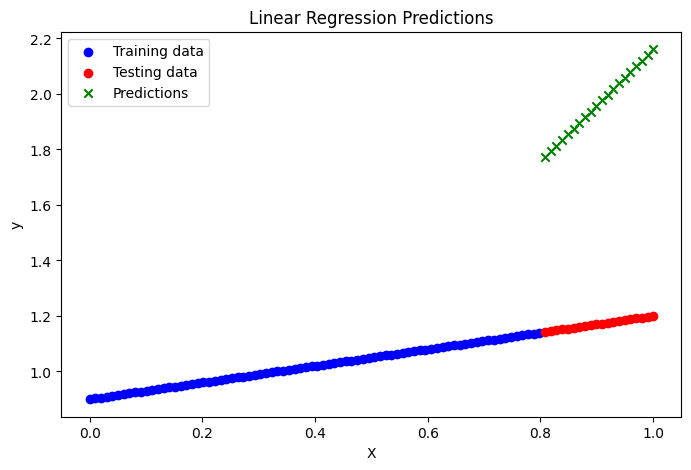

In [11]:
# Plot the predictions (these may need to be on a specific device)
plt.figure(figsize=(8,5))
plt.scatter(X_train.cpu(), y_train.cpu(), color='blue', label='Training data')
plt.scatter(X_test.cpu(), y_test.cpu(), color='red', label='Testing data')
plt.scatter(X_test.cpu(), y_pred, color='green', marker='x', label='Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Predictions')
plt.legend()
plt.show()

## 5. Save your trained model's `state_dict()` to file.
  * Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
  * Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [12]:
from pathlib import Path
import torch

# 1. Create models directory
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
model_path = models_dir / "linear_regression_model.pth"

# 3. Save the model state dict
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to models/linear_regression_model.pth


In [13]:
# Create new instance of model and load saved state dict (make sure to put it on the target device)
loaded_model = LinearRegressionModel().to(device)
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()

LinearRegressionModel()

In [14]:
# Make predictions with loaded model
with torch.no_grad():
    y_pred_loaded = loaded_model(X_test).cpu()  # GPU일 경우 CPU로 이동

# Compare to previous predictions
print("Are predictions equal to original model predictions? ",
      torch.allclose(y_pred_loaded, y_pred, atol=1e-6))

Are predictions equal to original model predictions?  True
